In [1]:
# Imports - run once and do not touch
import re
from pathlib import Path
from typing import List, Dict, Any, Tuple
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
LOG_PATH = Path(r"C:\Prgrm\BDCC_2025\results\results_prototypes_2025-12-23_00-20-14\overrides.txt")

# read the text (if encoding is broken, try cp1251)
try:
    text = LOG_PATH.read_text(encoding="utf-8")
except UnicodeDecodeError:
    text = LOG_PATH.read_text(encoding="cp1251")


In [3]:
# ====== SETTINGS EDIT HERE ======
METRIC = "UAR_BAH"   # e.g.: "UAR_BAH", "MF1_BAH", "RECALL_C2_NO_AMBIVALENCE_BAH"
SPLIT  = "TEST"      # "DEV" or "TEST"
TOP    = 40          # how many top rows to show
ASC    = False       # False = descending (best on top)
INCLUDE_BOTH = False # True - show both DEV and TEST; False - only the selected split

# ====== BELOW YOU CAN IGNORE ======

def normalize_box_text(raw: str) -> str:
    """Remove box-drawing and side bars, keep clean text."""
    lines = []
    for line in raw.splitlines():
        s = line.rstrip("\n")
        # skip frame lines
        if s.strip().startswith(("┌","└","┐","┘","─","—","━")):
            continue
        ss = s.strip()
        # trim outer vertical bars
        if ss.startswith("│") and ss.endswith("│") and len(ss) >= 2:
            ss = ss[1:-1]
        elif ss.startswith("│"):
            ss = ss[1:]
        else:
            ss = s
            if ss.rstrip().endswith("│"):
                ss = ss.rstrip()[:-1]
        lines.append(ss.strip())
    return "\n".join(lines)

# Step block: param names left of "=", values in parentheses, body until next "Step N" or end
BLOCK_RE = re.compile(
    r"Step\s+(?P<step>\d+):\s*(?P<hpnames>[^=]+?)=\s*\((?P<hpvals>[^)]*)\)\s*(?P<body>.*?)(?=\n\s*Step\s+\d+:|\Z)",
    re.DOTALL | re.UNICODE
)
SECTION_RE = re.compile(r"Results\s*\((DEV|TEST)\)\s*:\s*", re.IGNORECASE | re.UNICODE)
METRIC_LINE_RE = re.compile(r"^\s*(?P<key>[A-Z0-9_]+)\s*=\s*(?P<val>\d+(?:\.\d+)?)\s*$", re.UNICODE)

def coerce_value(s: str):
    s = s.strip()
    if not s or s.lower() in {"none", "null", "nan"}:
        return None
    if re.fullmatch(r"[+-]?\d+", s):
        try: return int(s)
        except: pass
    if re.fullmatch(r"[+-]?\d*\.\d+", s):
        try: return float(s)
        except: pass
    return s  # in case of textual hyperparameters

def parse_hp_names(names_raw: str) -> List[str]:
    # "a + b + c" -> ["a","b","c"]
    return [x.strip() for x in names_raw.split("+") if x.strip()]

def parse_hp_vals(vals_raw: str) -> List[Any]:
    # "1, 2, None" -> [1, 2, None]
    return [coerce_value(x) for x in vals_raw.split(",")]

def kv_from_names_vals(names: List[str], vals: List[Any]) -> Dict[str, Any]:
    out, n = {}, min(len(names), len(vals))
    for i in range(n): out[names[i]] = vals[i]
    for j in range(n, len(names)): out[names[j]] = None
    return out

def parse_section_metrics(text_block: str) -> Dict[str, float]:
    metrics = {}
    for line in text_block.splitlines():
        m = METRIC_LINE_RE.match(line.strip())
        if m:
            metrics[m.group("key").strip()] = float(m.group("val"))
    return metrics

def split_dev_test(body: str) -> Tuple[Dict[str, float], Dict[str, float]]:
    parts = list(SECTION_RE.split(body))
    dev, test = {}, {}
    for i in range(1, len(parts), 2):
        tag = parts[i].upper()
        text_part = parts[i+1]
        if tag == "DEV":
            dev = parse_section_metrics(text_part)
        elif tag == "TEST":
            test = parse_section_metrics(text_part)
    return dev, test

def parse_blocks_dynamic(text_src: str) -> List[Dict[str, Any]]:
    text_clean = normalize_box_text(text_src)
    rows = []
    for m in BLOCK_RE.finditer(text_clean):
        step = int(m.group("step"))
        hp_map = kv_from_names_vals(parse_hp_names(m.group("hpnames")),
                                    parse_hp_vals(m.group("hpvals")))
        dev, test = split_dev_test(m.group("body"))
        row = {"step": step, **hp_map}
        for k, v in dev.items():  row[f"{k}_DEV"]  = v
        for k, v in test.items(): row[f"{k}_TEST"] = v
        rows.append(row)
    rows.sort(key=lambda r: r["step"])
    return rows

def rows_to_dataframe_dynamic(rows: List[Dict[str, Any]]) -> pd.DataFrame:
    return pd.DataFrame(rows) if rows else pd.DataFrame()

def view_sorted_split(df: pd.DataFrame, metric: str, split: str,
                      top: int = 10, ascending: bool = False,
                      include_both: bool = False) -> pd.DataFrame:
    """
    Parameters (step + all non *_DEV/*_TEST), then the sort metric,
    then the remaining metrics of the selected split only (if include_both=False).
    """
    split = split.upper()
    sort_col = f"{metric}_{split}"

    # meta = step + all non-metrics (i.e., hyperparameters)
    meta_cols = ["step"] + [c for c in df.columns
                            if not (c.endswith("_DEV") or c.endswith("_TEST")) and c != "step"]

    # Which metrics to keep at all
    all_metric_cols = [c for c in df.columns if c.endswith("_DEV") or c.endswith("_TEST")]
    if include_both:
        keep_metric_cols = all_metric_cols[:]
    else:
        keep_metric_cols = [c for c in all_metric_cols if c.endswith(f"_{split}")]

    if sort_col not in keep_metric_cols:
        available = sorted(set(c.rsplit("_", 1)[0] for c in keep_metric_cols))
        raise ValueError(f"Column {sort_col} not found in selected split {split}. "
                         f"Available metrics: {available}")

    # Sort metric first, the rest after it in alphabetical order
    metric_cols_ordered = [sort_col] + [c for c in sorted(keep_metric_cols) if c != sort_col]
    ordered_cols = meta_cols + metric_cols_ordered

    out = df.loc[:, ordered_cols].sort_values(sort_col, ascending=ascending)
    return out.head(top)

# ==== Parse and display ====
_rows = parse_blocks_dynamic(text)
df = rows_to_dataframe_dynamic(_rows)

result_table = view_sorted_split(df, metric=METRIC, split=SPLIT,
                                 top=TOP, ascending=ASC, include_both=INCLUDE_BOTH)
result_table


,step,hidden_dim,num_transformer_heads,tr_layers,out_features,UAR_BAH_TEST,MF1_BAH_TEST,RECALL_C0_CONTROL_BAH_TEST,RECALL_C1_AMBIVALENCE_BAH_TEST,RECALL_C2_NO_AMBIVALENCE_BAH_TEST
2,3,128,2,5,512,0.7462,0.6540,0.6596,0.7970,0.7820
56,57,128,16,5,512,0.7460,0.6526,0.6574,0.7910,0.7895
38,39,128,8,5,512,0.7395,0.6436,0.6306,0.8060,0.7820
20,21,128,4,5,512,0.7323,0.6311,0.6060,0.8239,0.7669
58,59,128,16,7,256,0.7321,0.6234,0.5949,0.8119,0.7895
22,23,128,4,7,256,0.7288,0.6239,0.6016,0.8179,0.7669
29,30,128,4,10,512,0.7279,0.6197,0.5725,0.9045,0.7068
40,41,128,8,7,256,0.7269,0.6183,0.5926,0.8060,0.7820
4,5,128,2,7,256,0.7265,0.6201,0.5960,0.8090,0.7744
11,12,128,2,10,512,0.7218,0.6171,0.5737,0.9075,0.6842


In [2]:
# ====== SETTINGS EDIT HERE ======
METRIC = "UAR_BAH"   # e.g.: "UAR_BAH", "MF1_BAH", "RECALL_C2_NO_AMBIVALENCE_BAH"
SPLIT  = "TEST"      # "DEV" or "TEST"
TOP    = 10          # how many top rows to show
ASC    = False       # False = descending (best on top)
INCLUDE_BOTH = False # True - show both DEV and TEST; False - only the selected split

# ====== BELOW YOU CAN IGNORE ======

def normalize_box_text(raw: str) -> str:
    """Remove box-drawing and side bars, keep clean text."""
    lines = []
    for line in raw.splitlines():
        s = line.rstrip("\n")
        # skip frame lines
        if s.strip().startswith(("┌","└","┐","┘","─","—","━")):
            continue
        ss = s.strip()
        # trim outer vertical bars
        if ss.startswith("│") and ss.endswith("│") and len(ss) >= 2:
            ss = ss[1:-1]
        elif ss.startswith("│"):
            ss = ss[1:]
        else:
            ss = s
            if ss.rstrip().endswith("│"):
                ss = ss.rstrip()[:-1]
        lines.append(ss.strip())
    return "\n".join(lines)

# Step block: param names left of "=", values in parentheses, body until next "Step N" or end
BLOCK_RE = re.compile(
    r"Step\s+(?P<step>\d+):\s*(?P<hpnames>[^=]+?)=\s*\((?P<hpvals>[^)]*)\)\s*(?P<body>.*?)(?=\n\s*Step\s+\d+:|\Z)",
    re.DOTALL | re.UNICODE
)
SECTION_RE = re.compile(r"Results\s*\((DEV|TEST)\)\s*:\s*", re.IGNORECASE | re.UNICODE)
METRIC_LINE_RE = re.compile(r"^\s*(?P<key>[A-Z0-9_]+)\s*=\s*(?P<val>\d+(?:\.\d+)?)\s*$", re.UNICODE)

def coerce_value(s: str):
    s = s.strip()
    if not s or s.lower() in {"none", "null", "nan"}:
        return None
    if re.fullmatch(r"[+-]?\d+", s):
        try: return int(s)
        except: pass
    if re.fullmatch(r"[+-]?\d*\.\d+", s):
        try: return float(s)
        except: pass
    return s  # in case of textual hyperparameters

def parse_hp_names(names_raw: str) -> List[str]:
    # "a + b + c" -> ["a","b","c"]
    return [x.strip() for x in names_raw.split("+") if x.strip()]

def parse_hp_vals(vals_raw: str) -> List[Any]:
    # "1, 2, None" -> [1, 2, None]
    return [coerce_value(x) for x in vals_raw.split(",")]

def kv_from_names_vals(names: List[str], vals: List[Any]) -> Dict[str, Any]:
    out, n = {}, min(len(names), len(vals))
    for i in range(n): out[names[i]] = vals[i]
    for j in range(n, len(names)): out[names[j]] = None
    return out

def parse_section_metrics(text_block: str) -> Dict[str, float]:
    metrics = {}
    for line in text_block.splitlines():
        m = METRIC_LINE_RE.match(line.strip())
        if m:
            metrics[m.group("key").strip()] = float(m.group("val"))
    return metrics

def split_dev_test(body: str) -> Tuple[Dict[str, float], Dict[str, float]]:
    parts = list(SECTION_RE.split(body))
    dev, test = {}, {}
    for i in range(1, len(parts), 2):
        tag = parts[i].upper()
        text_part = parts[i+1]
        if tag == "DEV":
            dev = parse_section_metrics(text_part)
        elif tag == "TEST":
            test = parse_section_metrics(text_part)
    return dev, test

def parse_blocks_dynamic(text_src: str) -> List[Dict[str, Any]]:
    text_clean = normalize_box_text(text_src)
    rows = []
    for m in BLOCK_RE.finditer(text_clean):
        step = int(m.group("step"))
        hp_map = kv_from_names_vals(parse_hp_names(m.group("hpnames")),
                                    parse_hp_vals(m.group("hpvals")))
        dev, test = split_dev_test(m.group("body"))
        row = {"step": step, **hp_map}
        for k, v in dev.items():  row[f"{k}_DEV"]  = v
        for k, v in test.items(): row[f"{k}_TEST"] = v
        rows.append(row)
    rows.sort(key=lambda r: r["step"])
    return rows

def rows_to_dataframe_dynamic(rows: List[Dict[str, Any]]) -> pd.DataFrame:
    return pd.DataFrame(rows) if rows else pd.DataFrame()

def view_sorted_split(df: pd.DataFrame, metric: str, split: str,
                      top: int = 10, ascending: bool = False,
                      include_both: bool = False) -> pd.DataFrame:
    """
    Parameters (step + all non *_DEV/*_TEST), then the sort metric,
    then the remaining metrics of the selected split only (if include_both=False).
    """
    split = split.upper()
    sort_col = f"{metric}_{split}"

    # meta = step + all non-metrics (i.e., hyperparameters)
    meta_cols = ["step"] + [c for c in df.columns
                            if not (c.endswith("_DEV") or c.endswith("_TEST")) and c != "step"]

    # Which metrics to keep at all
    all_metric_cols = [c for c in df.columns if c.endswith("_DEV") or c.endswith("_TEST")]
    if include_both:
        keep_metric_cols = all_metric_cols[:]
    else:
        keep_metric_cols = [c for c in all_metric_cols if c.endswith(f"_{split}")]

    if sort_col not in keep_metric_cols:
        available = sorted(set(c.rsplit("_", 1)[0] for c in keep_metric_cols))
        raise ValueError(f"Column {sort_col} not found in selected split {split}. "
                         f"Available metrics: {available}")

    # Sort metric first, the rest after it in alphabetical order
    metric_cols_ordered = [sort_col] + [c for c in sorted(keep_metric_cols) if c != sort_col]
    ordered_cols = meta_cols + metric_cols_ordered

    out = df.loc[:, ordered_cols].sort_values(sort_col, ascending=ascending)
    return out.head(top)

# ==== Parse and display ====
_rows = parse_blocks_dynamic(text)
df = rows_to_dataframe_dynamic(_rows)

result_table = view_sorted_split(df, metric=METRIC, split=SPLIT,
                                 top=TOP, ascending=ASC, include_both=INCLUDE_BOTH)
result_table


NameError: name 're' is not defined

In [30]:
import os
import pickle
import numpy as np

pkl_path = r"pkl_logits/transformer_bah_best.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

type(data), len(data), list(data.keys())[:5]


(dict,
 1364,
 ['E:/BAH//no_ambivalence/test_labels/WLr_TYHX1L4\\segments\\WLr_TYHX1L4_001.mp4',
  'E:/BAH//no_ambivalence/test_labels/WLr_TYHX1L4\\segments\\WLr_TYHX1L4_002.mp4',
  'E:/BAH//no_ambivalence/test_labels/WLr_TYHX1L4\\segments\\WLr_TYHX1L4_003.mp4',
  'E:/BAH//no_ambivalence/test_labels/WLr_TYHX1L4\\segments\\WLr_TYHX1L4_004.mp4',
  'E:/BAH//no_ambivalence/test_labels/WLr_TYHX1L4\\segments\\WLr_TYHX1L4_005.mp4'])

In [31]:
# --- [Code] Decide which keys are inside (prob vs logits) ---
first_key = next(iter(data.keys()))
sample = data[first_key]
print("Example file:", first_key)
print("Inner keys:", list(sample.keys()))

# Automatically choose field names (final_prob vs final_logits)
def pick_key(d, prefer):
    for k in prefer:
        if k in d:
            return k
    return None

FINAL_K = pick_key(sample, ["final_prob", "final_logits"])
CLS_K   = pick_key(sample, ["cls_prob", "cls_logits"])
PROTO_K = pick_key(sample, ["proto_prob", "proto_logits"])
EMB_K   = pick_key(sample, ["embeddings", "features", "feat"])

print("Detected keys:")
print("FINAL_K =", FINAL_K)
print("CLS_K   =", CLS_K)
print("PROTO_K =", PROTO_K)
print("EMB_K   =", EMB_K)


Example file: E:/BAH//no_ambivalence/test_labels/WLr_TYHX1L4\segments\WLr_TYHX1L4_001.mp4
Inner keys: ['name', 'final_prob', 'cls_prob', 'proto_prob', 'embeddings']
Detected keys:
FINAL_K = final_prob
CLS_K   = cls_prob
PROTO_K = proto_prob
EMB_K   = embeddings


In [32]:
# --- [Code] Build matrices: filenames, final_probs, cls_probs, proto_probs, embeddings ---
files = list(data.keys())

final_mat = []
cls_mat   = []
proto_mat = []
emb_mat   = []

for fn in files:
    rec = data[fn]
    final_mat.append(rec[FINAL_K])
    emb_mat.append(rec[EMB_K])

    # cls/proto can be None
    cls_mat.append(rec[CLS_K] if (CLS_K is not None and rec[CLS_K] is not None) else None)
    proto_mat.append(rec[PROTO_K] if (PROTO_K is not None and rec[PROTO_K] is not None) else None)

final_mat = np.stack(final_mat, axis=0)  # [N, C]
emb_mat   = np.stack(emb_mat, axis=0)    # [N, D]

has_cls   = any(x is not None for x in cls_mat)
has_proto = any(x is not None for x in proto_mat)

if has_cls:
    cls_mat = np.stack([x if x is not None else np.full_like(final_mat[0], np.nan) for x in cls_mat], axis=0)
else:
    cls_mat = None

if has_proto:
    proto_mat = np.stack([x if x is not None else np.full_like(final_mat[0], np.nan) for x in proto_mat], axis=0)
else:
    proto_mat = None

print("N =", len(files))
print("final_mat shape:", final_mat.shape)
print("emb_mat shape:", emb_mat.shape)
print("cls_mat:", None if cls_mat is None else cls_mat.shape)
print("proto_mat:", None if proto_mat is None else proto_mat.shape)


N = 1364
final_mat shape: (1364, 3)
emb_mat shape: (1364, 128)
cls_mat: (1364, 3)
proto_mat: (1364, 3)


In [33]:
# --- [Code] Quick view of several records ---
def topk(prob_vec, k=3):
    idx = np.argsort(prob_vec)[::-1][:k]
    return list(zip(idx.tolist(), prob_vec[idx].tolist()))

for i in range(3):
    fn = files[i]
    print("\nFILE:", fn)
    print("final top3:", topk(final_mat[i], 3))
    if cls_mat is not None:
        print("cls   top3:", topk(cls_mat[i], 3))
    if proto_mat is not None:
        print("proto top3:", topk(proto_mat[i], 3))
    print("emb norm:", float(np.linalg.norm(emb_mat[i])))



FILE: E:/BAH//no_ambivalence/test_labels/WLr_TYHX1L4\segments\WLr_TYHX1L4_001.mp4
final top3: [(2, 0.8994766473770142), (0, 0.09267550706863403), (1, 0.007847846485674381)]
cls   top3: [(2, nan), (1, nan), (0, nan)]
proto top3: [(2, nan), (1, nan), (0, nan)]
emb norm: 52.89813995361328

FILE: E:/BAH//no_ambivalence/test_labels/WLr_TYHX1L4\segments\WLr_TYHX1L4_002.mp4
final top3: [(2, 0.8894316554069519), (0, 0.10547500103712082), (1, 0.005093246232718229)]
cls   top3: [(2, nan), (1, nan), (0, nan)]
proto top3: [(2, nan), (1, nan), (0, nan)]
emb norm: 53.09891891479492

FILE: E:/BAH//no_ambivalence/test_labels/WLr_TYHX1L4\segments\WLr_TYHX1L4_003.mp4
final top3: [(2, 0.8541585206985474), (0, 0.14144961535930634), (1, 0.004391865339130163)]
cls   top3: [(2, nan), (1, nan), (0, nan)]
proto top3: [(2, nan), (1, nan), (0, nan)]
emb norm: 53.22282028198242


In [27]:
# --- [Code] If needed: build a dataset for RandomForest ---
# X = embeddings (or embeddings + final_prob)
X_emb = emb_mat
X_stack = np.concatenate([emb_mat, final_mat], axis=1)  # [N, D+C]

print("X_emb:", X_emb.shape)
print("X_stack:", X_stack.shape)


X_emb: (1364, 128)
X_stack: (1364, 131)


In [5]:
import os, csv, pickle
import numpy as np
import torch
import torch.nn.functional as F
import toml

# --- Settings ---
PKL = "pkl_logits/prototypes_bah_best.pkl"   # or transformer_bah_best.pkl
SPLIT = "test"  # if there is no test, use "dev" or "val"
CFG_PATH = "config.toml"
# ------------------

cfg = toml.load(CFG_PATH)
labels = {}

def map_label(ds_name, raw):
    raw = int(raw)
    s = ds_name.lower()
    if "ambivalence" in s:
        return 1 if raw == 1 else 0
    if "no_ambivalence" in s:
        return 2 if raw == 1 else 0
    return 0

# 1) Build map: video_path -> label
for ds_name, ds_cfg in cfg["datasets"].items():
    if not ds_name.lower().startswith("bah_"):
        continue
    csv_path = ds_cfg["csv_path"].format(base_dir=ds_cfg["base_dir"], split=SPLIT)
    video_dir = ds_cfg["video_dir"].format(base_dir=ds_cfg["base_dir"], split=SPLIT)
    if not os.path.exists(csv_path):
        continue

    with open(csv_path, newline="", encoding="utf-8") as f:
        r = csv.DictReader(f)
        for row in r:
            vid = str(row["video_id"])
            seg = str(row["segment_file"])
            vpath = os.path.normpath(os.path.join(video_dir, vid, "segments", seg))
            labels[vpath] = map_label(ds_name, row["diagnosis"])

print("labels loaded:", len(labels))

# 2) Load embeddings
with open(PKL, "rb") as f:
    data = pickle.load(f)

X, y = [], []
for k, d in data.items():
    key = os.path.normpath(k.split("__dup")[0])
    lab = labels.get(key)
    if lab is None:
        continue
    X.append(d["embeddings"])  # <-- embeddings only here
    y.append(lab)

X = torch.from_numpy(np.stack(X)).float()
y = torch.tensor(y)
print("samples:", X.shape[0], "dim:", X.shape[1])

# 3) Centroids
C = int(y.max().item()) + 1
centroids = torch.stack([X[y == c].mean(0) for c in range(C)])

# 4) Centroid classifier (cosine)
Xn = F.normalize(X, dim=1)
Cn = F.normalize(centroids, dim=1)
logits = Xn @ Cn.t()
pred = logits.argmax(1)
acc = (pred == y).float().mean().item()

# 5) Intra / inter (euclidean)
intra = torch.stack([(X[y == c] - centroids[c]).norm(dim=1).mean() for c in range(C)]).mean().item()
inter = torch.pdist(centroids, p=2).mean().item()
ratio = inter / (intra + 1e-8)

print(f"centroid_acc = {acc:.4f}")
print(f"intra = {intra:.4f}  inter = {inter:.4f}  inter/intra = {ratio:.4f}")


labels loaded: 1364
samples: 1364 dim: 128
centroid_acc = 0.5499
intra = 34.1141  inter = 45.5558  inter/intra = 1.3354


In [7]:
import os, csv, pickle
import numpy as np
import torch
import torch.nn.functional as F
import toml

# --- Settings ---
PKL = "pkl_logits/prototypes_bah_best.pkl"
SPLIT = "test"  # dev/val/test
CFG_PATH = "config.toml"
# ------------------

cfg = toml.load(CFG_PATH)
labels = {}

def map_label(ds_name, raw):
    raw = int(raw)
    s = ds_name.lower()
    if "ambivalence" in s:
        return 1 if raw == 1 else 0
    if "no_ambivalence" in s:
        return 2 if raw == 1 else 0
    return 0

# labels: video_path -> label
for ds_name, ds_cfg in cfg["datasets"].items():
    if not ds_name.lower().startswith("bah_"):
        continue
    csv_path = ds_cfg["csv_path"].format(base_dir=ds_cfg["base_dir"], split=SPLIT)
    video_dir = ds_cfg["video_dir"].format(base_dir=ds_cfg["base_dir"], split=SPLIT)
    if not os.path.exists(csv_path):
        continue
    with open(csv_path, newline="", encoding="utf-8") as f:
        r = csv.DictReader(f)
        for row in r:
            vid = str(row["video_id"])
            seg = str(row["segment_file"])
            vpath = os.path.normpath(os.path.join(video_dir, vid, "segments", seg))
            labels[vpath] = map_label(ds_name, row["diagnosis"])

print("labels loaded:", len(labels))

# load pkl
with open(PKL, "rb") as f:
    data = pickle.load(f)

X, y = [], []
for k, d in data.items():
    key = os.path.normpath(k.split("__dup")[0])
    lab = labels.get(key)
    if lab is None:
        continue
    X.append(d["embeddings"])
    y.append(lab)

if not X:
    raise RuntimeError("No matched samples. Check SPLIT/CFG_PATH/PKL.")

X = torch.from_numpy(np.stack(X)).float()
y = torch.tensor(y)
print("samples:", X.shape[0], "dim:", X.shape[1])

C = int(y.max().item()) + 1
centroids = torch.stack([X[y == c].mean(0) for c in range(C)])

# --- Centroid classifier accuracy ---
# cosine
Xn = F.normalize(X, dim=1)
Cn = F.normalize(centroids, dim=1)
logits_cos = Xn @ Cn.t()
acc_cos = (logits_cos.argmax(1) == y).float().mean().item()

# euclid (raw)
d_raw = torch.cdist(X, centroids, p=2)
acc_euc = (d_raw.argmin(1) == y).float().mean().item()

print(f"centroid_acc_cosine = {acc_cos:.4f}")
print(f"centroid_acc_euclid = {acc_euc:.4f}")

# --- intra/inter distances ---
# Euclid on raw embeddings
intra_euc_raw = torch.stack([
    (X[y == c] - centroids[c]).norm(dim=1).mean()
    for c in range(C)
]).mean().item()

inter_euc_raw = torch.pdist(centroids, p=2).mean().item()

print(f"intra_euclid_raw = {intra_euc_raw:.4f}")
print(f"inter_euclid_raw = {inter_euc_raw:.4f}")
print(f"inter/intra (euclid_raw) = {inter_euc_raw/(intra_euc_raw+1e-8):.4f}")

# Euclid on normalized embeddings (~ cosine geometry)
centroids_n = F.normalize(centroids, dim=1)
intra_euc_norm = torch.stack([
    (Xn[y == c] - centroids_n[c]).norm(dim=1).mean()
    for c in range(C)
]).mean().item()

inter_euc_norm = torch.pdist(centroids_n, p=2).mean().item()

print(f"intra_euclid_norm = {intra_euc_norm:.4f}")
print(f"inter_euclid_norm = {inter_euc_norm:.4f}")
print(f"inter/intra (euclid_norm) = {inter_euc_norm/(intra_euc_norm+1e-8):.4f}")

# Cosine distances (1 - cosine similarity)
intra_cos = torch.stack([
    (1 - (Xn[y == c] @ Cn[c])).mean()
    for c in range(C)
]).mean().item()

inter_cos = (1 - (Cn @ Cn.t())).triu(1)
inter_cos = inter_cos[inter_cos > 0].mean().item()

print(f"intra_cosine = {intra_cos:.4f}")
print(f"inter_cosine = {inter_cos:.4f}")
print(f"inter/intra (cosine) = {inter_cos/(intra_cos+1e-8):.4f}")


labels loaded: 1364
samples: 1364 dim: 128
centroid_acc_cosine = 0.7243
centroid_acc_euclid = 0.7331
intra_euclid_raw = 40.0676
inter_euclid_raw = 25.8667
inter/intra (euclid_raw) = 0.6456
intra_euclid_norm = 0.9102
inter_euclid_norm = 0.9061
inter/intra (euclid_norm) = 0.9955
intra_cosine = 0.4263
inter_cosine = 0.4117
inter/intra (cosine) = 0.9658


In [9]:
# pred already computed via centroid classifier
counts = torch.bincount(y)
per_class_acc = []
for c in range(C):
    m = (y == c)
    acc_c = (pred[m] == c).float().mean().item() if m.any() else float("nan")
    per_class_acc.append(acc_c)

uar = np.nanmean(per_class_acc)
print("per_class_acc:", per_class_acc)
print("UAR_centroid:", uar)
print("class_counts:", counts.tolist())


per_class_acc: [0.3805803656578064, 0.9104477763175964, 0.7819548845291138]
UAR_centroid: 0.6909943421681722
class_counts: [896, 335, 133]


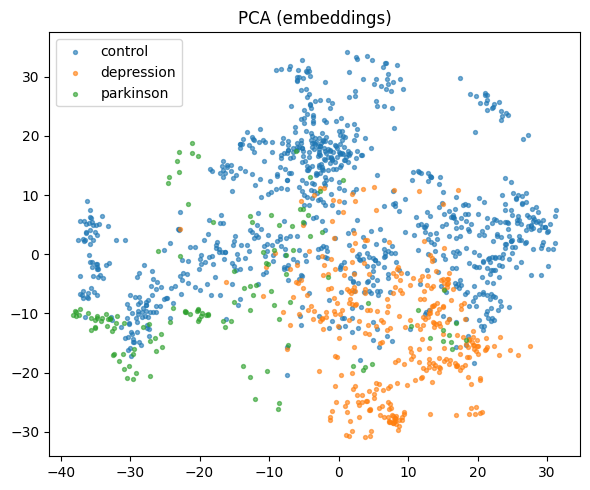

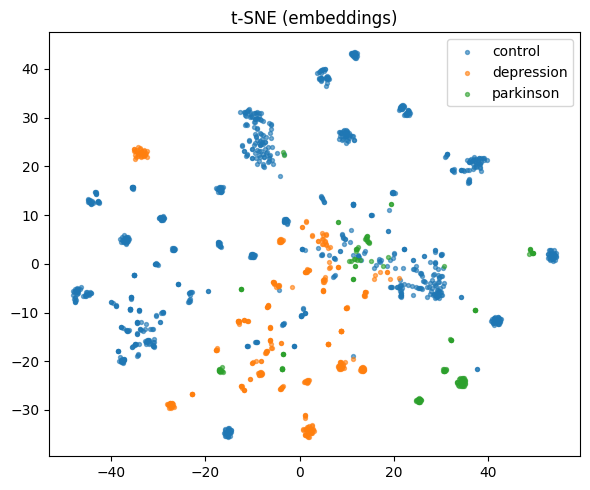

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# X: torch.Tensor [N, D], y: torch.Tensor [N]
X_np = X.detach().cpu().numpy()
y_np = y.detach().cpu().numpy()

# for large datasets you can subsample
max_n = 2000
if X_np.shape[0] > max_n:
    idx = np.random.RandomState(42).choice(X_np.shape[0], max_n, replace=False)
    X_np = X_np[idx]
    y_np = y_np[idx]

# ----- PCA 2D (via SVD) -----
Xc = X_np - X_np.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
X_pca = Xc @ Vt[:2].T

plt.figure(figsize=(6, 5))
for cls, name, color in [(0, "control", "tab:blue"),
                         (1, "ambivalence", "tab:orange"),
                         (2, "no_ambivalence", "tab:green")]:
    m = (y_np == cls)
    plt.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.6, label=name, c=color)
plt.title("PCA (embeddings)")
plt.legend()
plt.tight_layout()
plt.show()

# ----- t-SNE (if sklearn is available) -----
try:
    from sklearn.manifold import TSNE

    X_tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=42,
    ).fit_transform(X_np)

    plt.figure(figsize=(6, 5))
    for cls, name, color in [(0, "control", "tab:blue"),
                             (1, "ambivalence", "tab:orange"),
                             (2, "no_ambivalence", "tab:green")]:
        m = (y_np == cls)
        plt.scatter(X_tsne[m, 0], X_tsne[m, 1], s=8, alpha=0.6, label=name, c=color)
    plt.title("t-SNE (embeddings)")
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("t-SNE skipped:", e)
